# Disky / Spiral Lens — Single-Sersic vs. Two-Component Light

## Learning to Autolens / Examples / disky_spiral_lens

---

**Problem.** Real lens galaxies often have **two light components at different position angles** — a high-Sersic-index bulge and a lower-n disk that's more flattened and rotated. A single-Sersic light profile *cannot* capture this morphology; it's mathematically a single ellipse in surface brightness.

This example shows what that looks like in practice:
- Simulated lens has bulge (PA≈0°, *n*=4, *R_e*=0.45″) + disk (PA≈35°, *n*=1, *R_e*=1.0″).
- Mass is Isothermal + shear, aligned with the bulge PA.
- Source is a compact Sersic at $z=1.6$.

**Pedagogical payoff.** Fit it two ways and compare:
1. **Single Sersic**: leaves coherent residuals at the lens centre where the bulge and disk don't both fit.
2. **Bulge + disk** (two Sersics, independent ell_comps): subtracts the lens light cleanly.

The log-evidence difference quantifies the value of the 7 extra disk parameters. This is the simpler cousin of the Module 09 MGE technique — MGE handles arbitrary morphology with ~10 components; here we just demonstrate the *principle* with 2.

**Prerequisites.** Mod 03 (free fit), Mod 04 (SLaM), Mod 09 (MGE / linear light profiles).


In [1]:
import os, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, IFrame, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline
print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2026.4.13.6


In [2]:
RESULTS_ROOT = Path("results")

def show_result(stage_name):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"(no results for stage {stage_name!r})")
        return
    sp = stage_dir / "summary.json"
    if sp.exists():
        s = json.loads(sp.read_text())
        display(Markdown(
            f"### `{stage_name}`\n"
            f"- log evidence: **{s.get('log_evidence'):.2f}**\n"
            f"- χ²/N = **{s.get('chi_squared_per_pixel'):.3f}**\n"
            f"- max |normalized residual| = **{s.get('max_abs_normalized_residual'):.2f} σ**"
        ))
    fp = stage_dir / "fit_subplot.png"
    if fp.exists():
        display(Image(filename=str(fp)))

---
## 1. The data

A 120×120 HST-like cutout (pixel_scales=0.05″) of the lens + single-source system. Running `mocks/generate_mock.py` regenerates it.

2026-04-23 22:32:58,050 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 9856 image-pixels


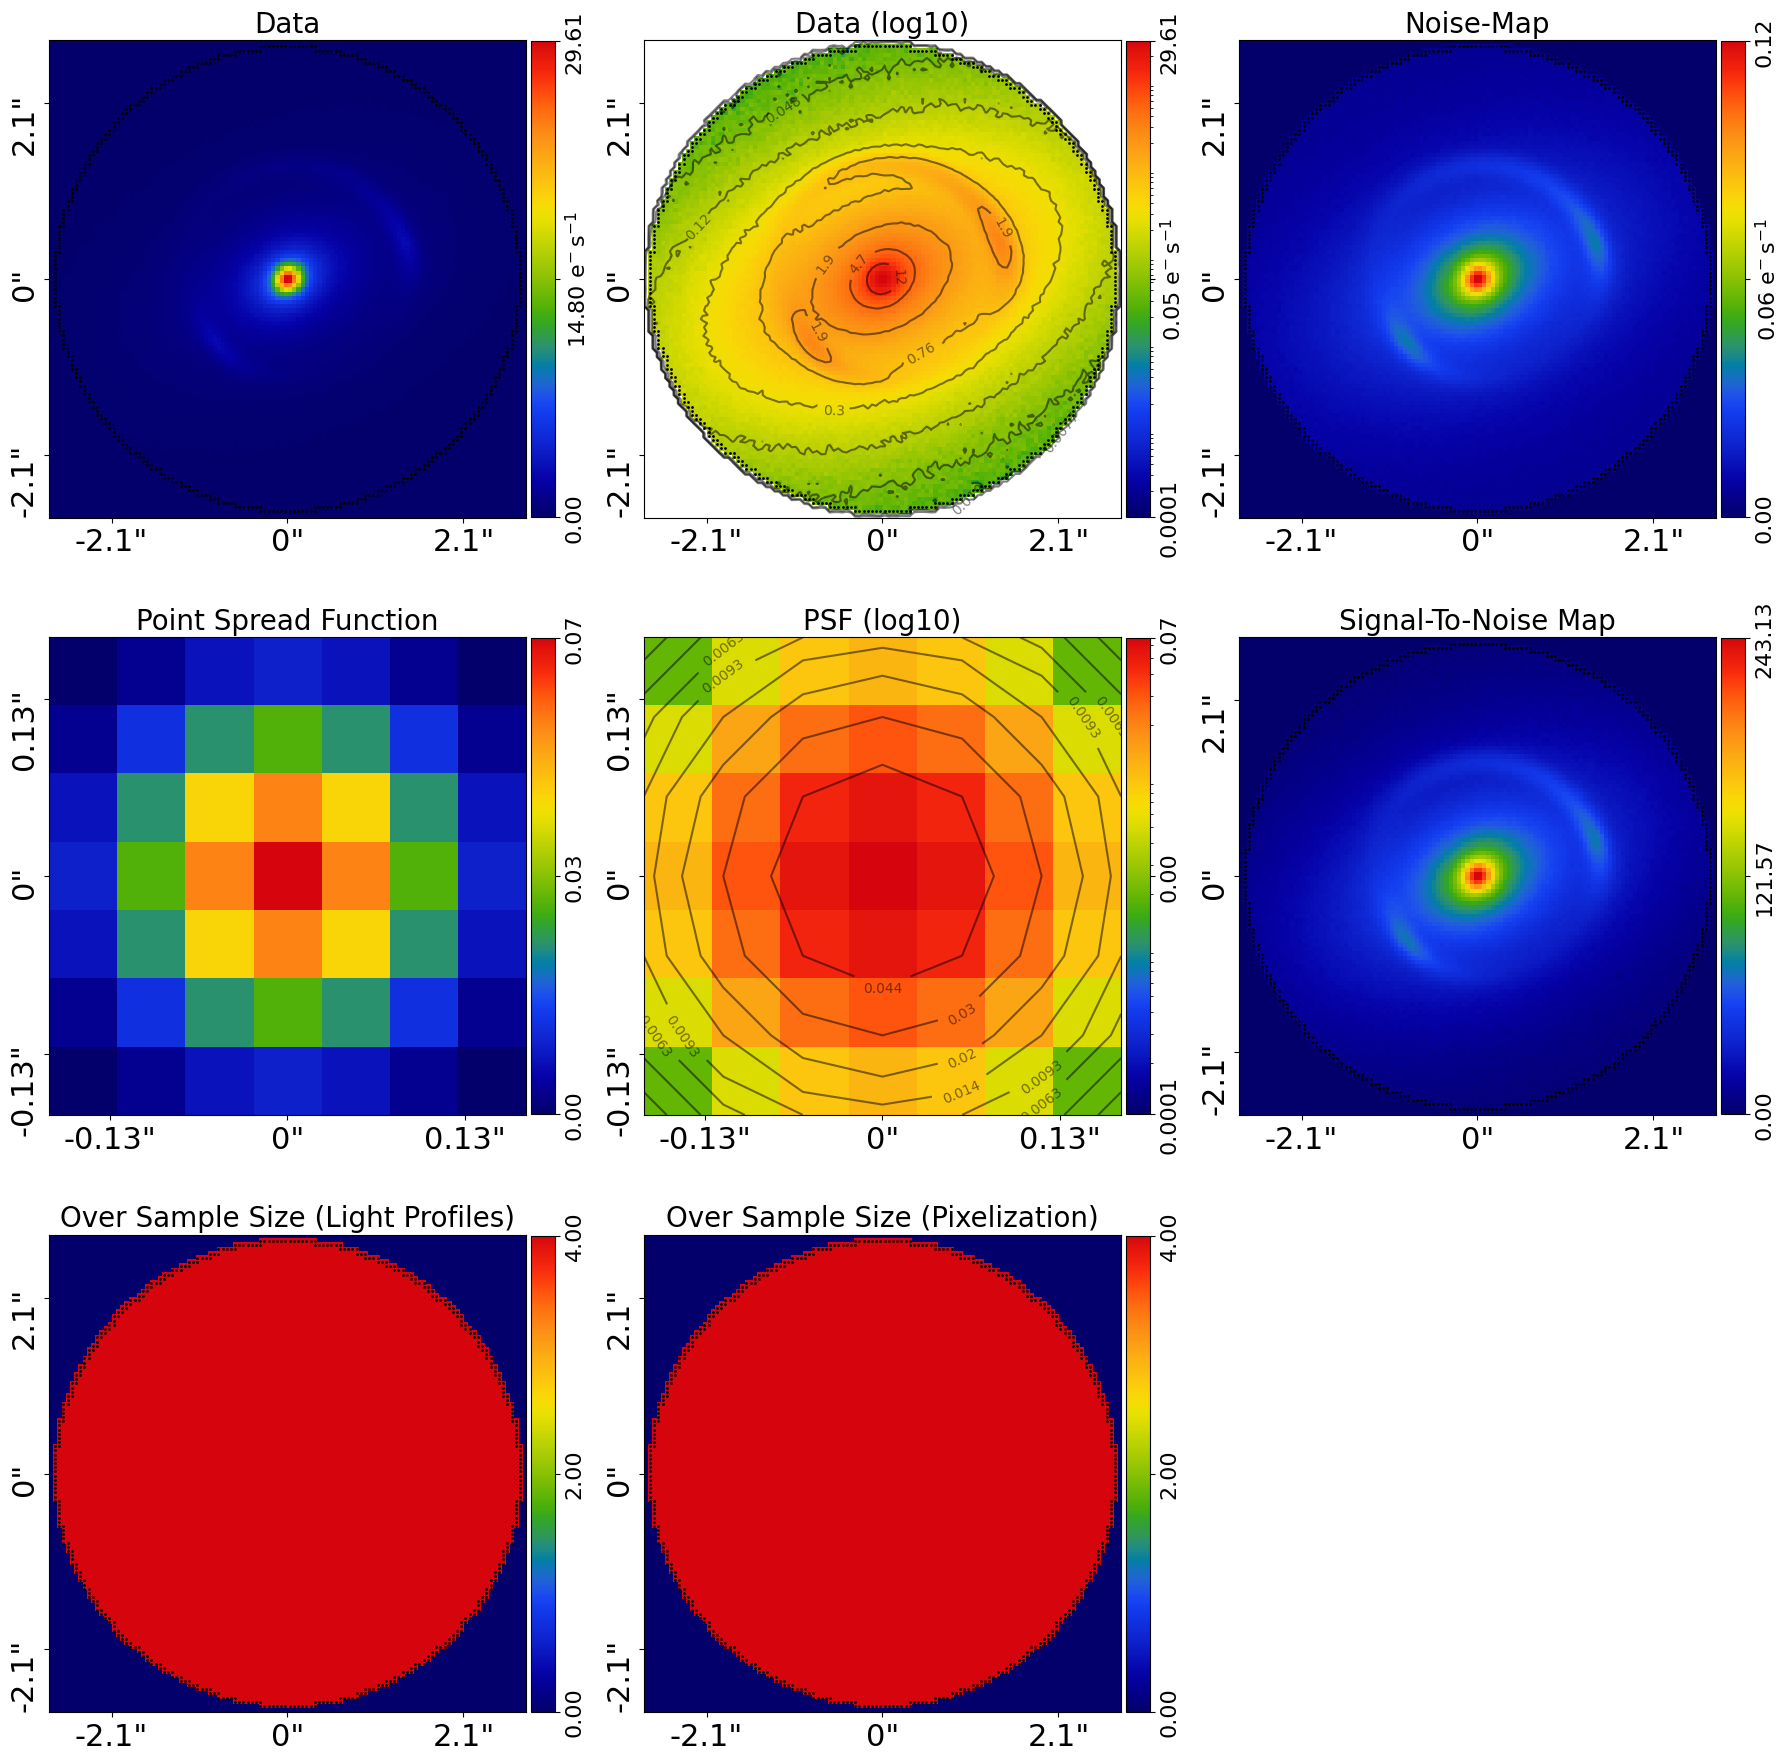

In [3]:
dataset = al.Imaging.from_fits(
    data_path      = Path("mocks") / "mock_image.fits",
    noise_map_path = Path("mocks") / "mock_noise.fits",
    psf_path       = Path("mocks") / "mock_psf.fits",
    pixel_scales   = 0.05,
)
mask = al.Mask2D.circular(
    shape_native = dataset.shape_native,
    pixel_scales = dataset.pixel_scales,
    radius       = 2.8,
)
dataset = dataset.apply_mask(mask=mask)
aplt.subplot_imaging_dataset(dataset=dataset)

---
## 2. The two model variants

Full details in `Modules/10_Cluster_Computing/scripts/fit_example_disky_spiral_lens.py`.

**Variant 1 — single Sersic (17 free parameters):**

| Component | Profile | Notes |
|---|---|---|
| Lens light | one `al.lp.Sersic` | centre tied, wide ell_comps, n ∈ [0.8, 5] |
| Lens mass | `al.mp.Isothermal` | `einstein_radius ~ UniformPrior(0.5, 3)` |
| Shear | `al.mp.ExternalShear` | Gaussian(0, 0.1) |
| Source | `al.lp.SersicCore` | centre Gaussian(0, 0.3), compact R_e |

**Variant 2 — bulge + disk (24 free parameters):**

| Component | Profile | Notes |
|---|---|---|
| Lens bulge | `al.lp.Sersic` | n ∈ [2, 6], R_e ∈ [0.1, 1.5] |
| Lens disk | `al.lp.Sersic` | n ∈ [0.5, 2], R_e ∈ [0.3, 3], **INDEPENDENT ell_comps** |
| Lens mass + shear + source | same as Variant 1 | |

The bulge and disk share a centre (tied) but have **independent ell_comps**, which is what lets them represent different position angles.

---
## 3. Results (loaded from Cannon)

Submitted via:

```bash
sbatch --export=ALL,EXAMPLE=disky_spiral_lens,FIT_EXTRA_ARGS=--part=all \
    Modules/10_Cluster_Computing/scripts/submit_cannon.slurm
```

`--part=all` runs both variants sequentially into `results/single_sersic_fit/` and `results/bulge_disk_fit/`.

### `single_sersic_fit`
- log evidence: **-33255.46**
- χ²/N = **13.576**
- max |normalized residual| = **43.19 σ**

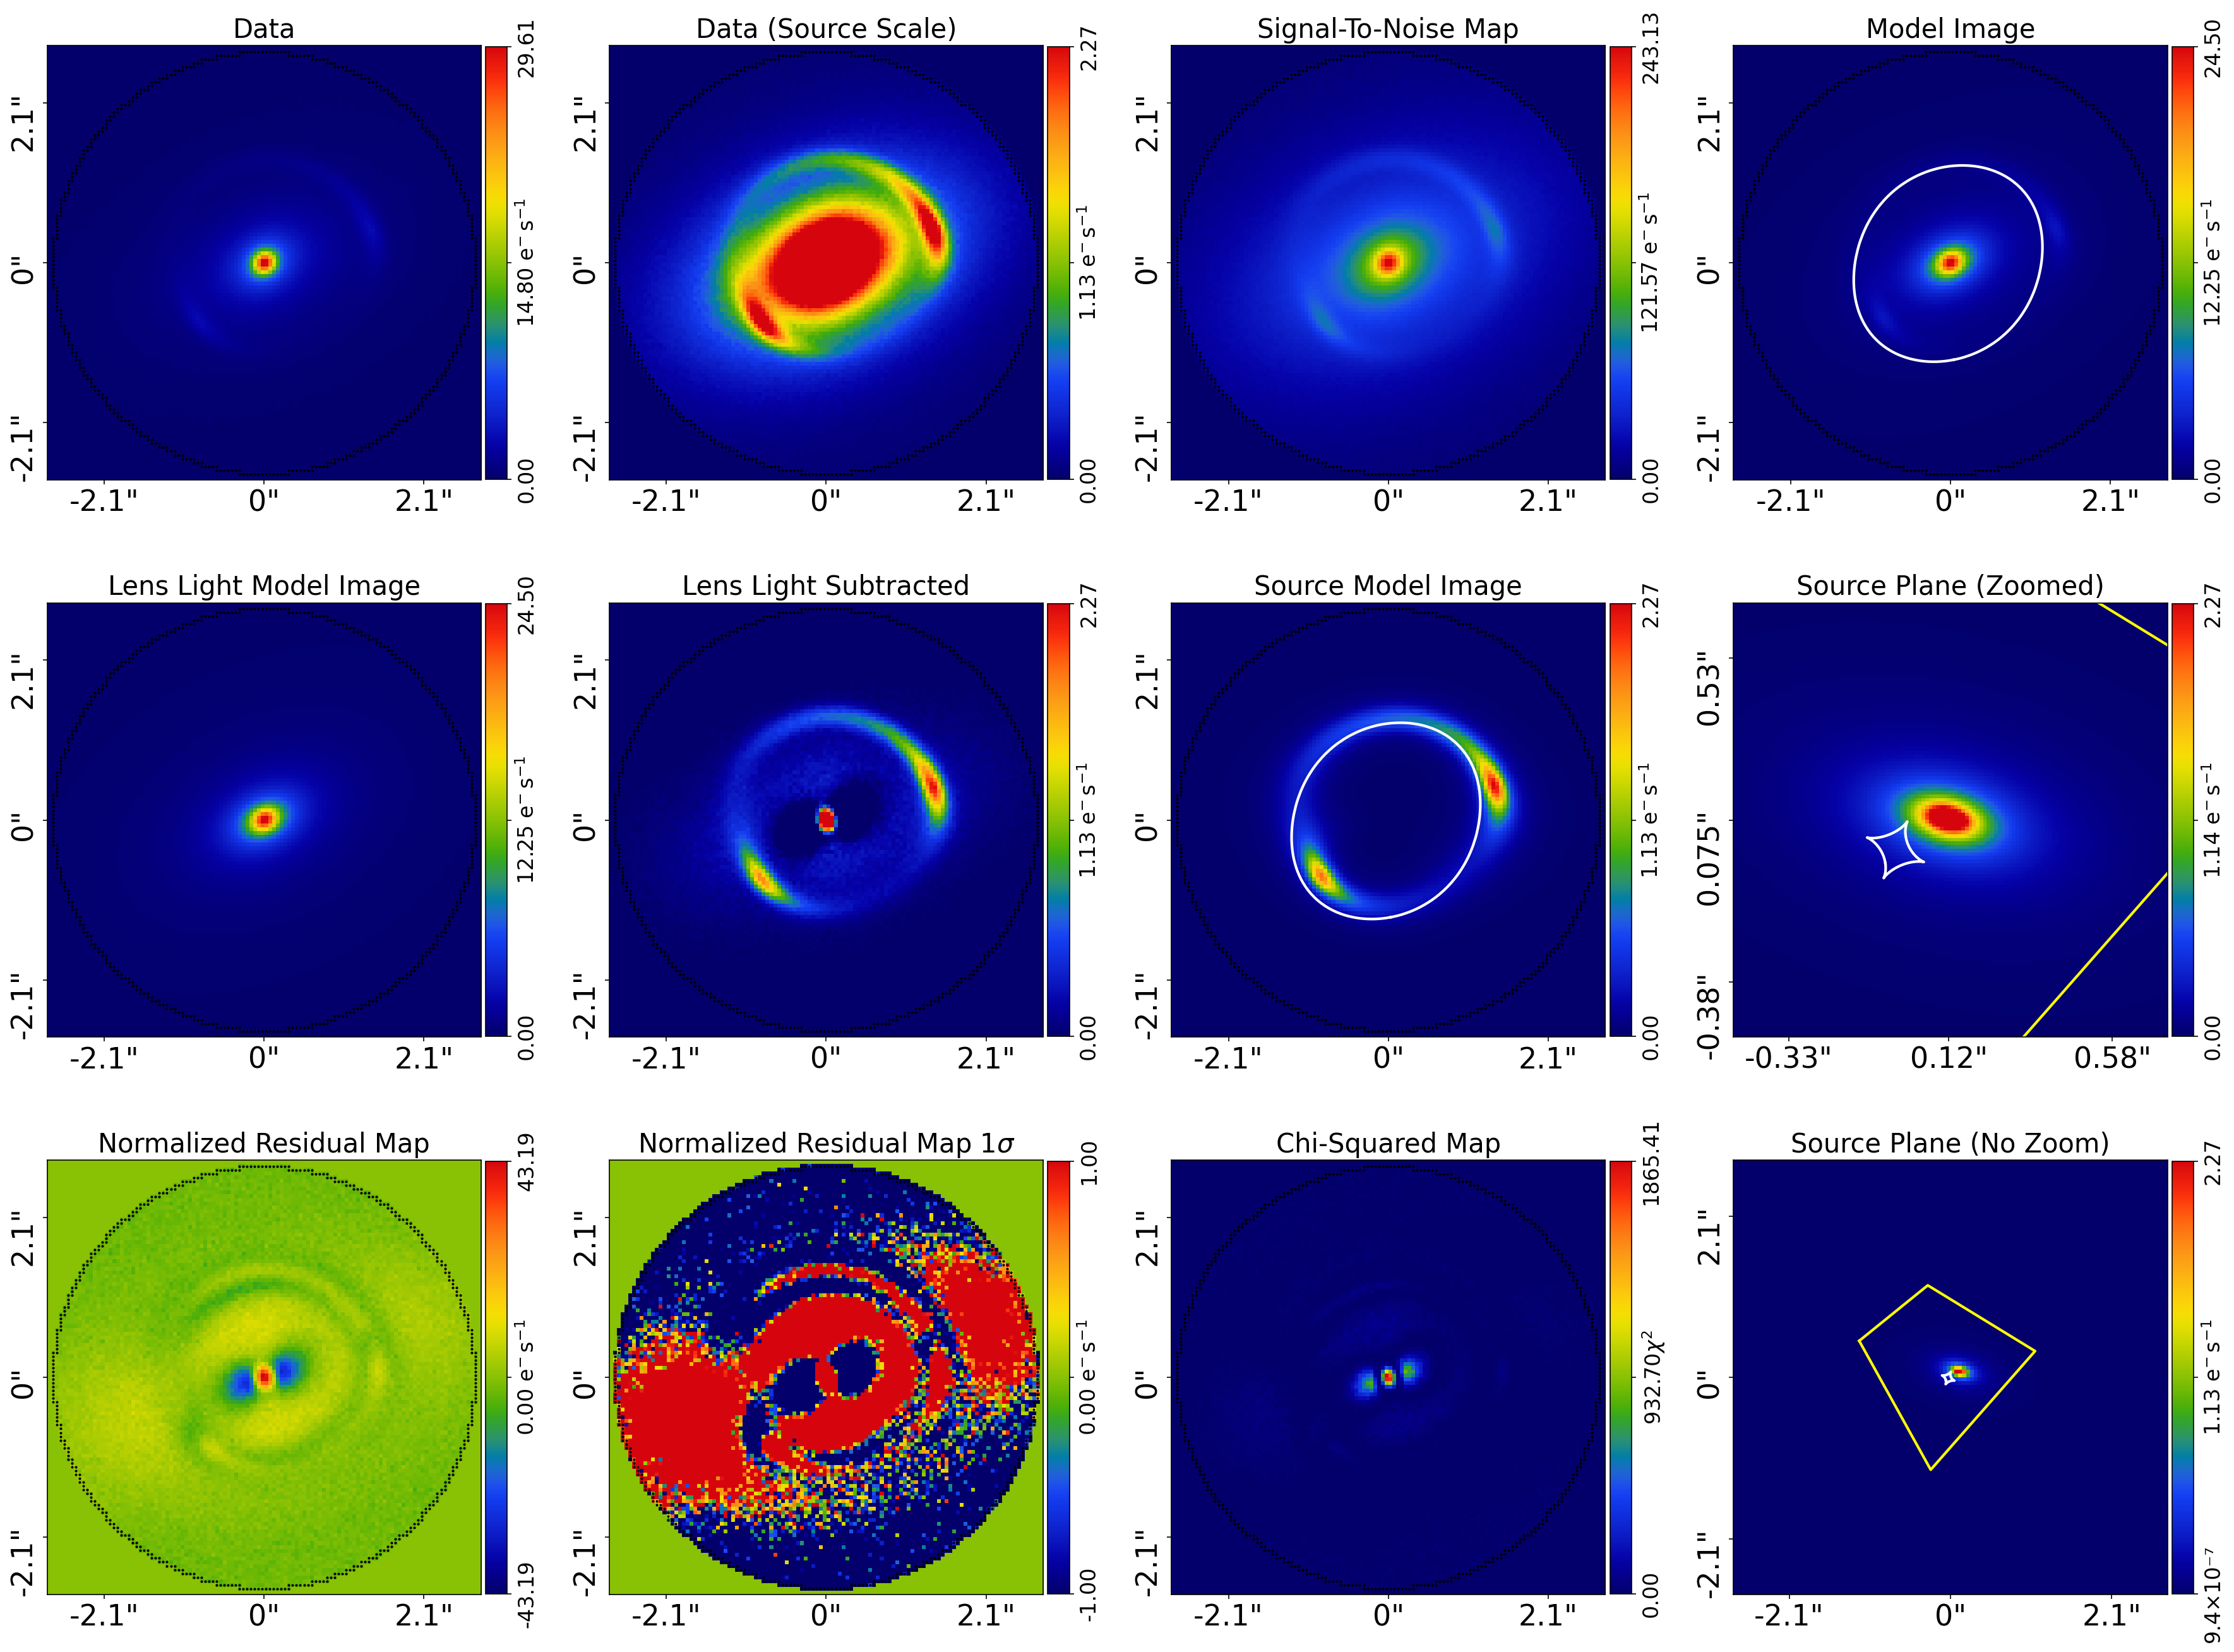

In [4]:
show_result("single_sersic_fit")

### `bulge_disk_fit`
- log evidence: **28713.68**
- χ²/N = **0.996**
- max |normalized residual| = **4.21 σ**

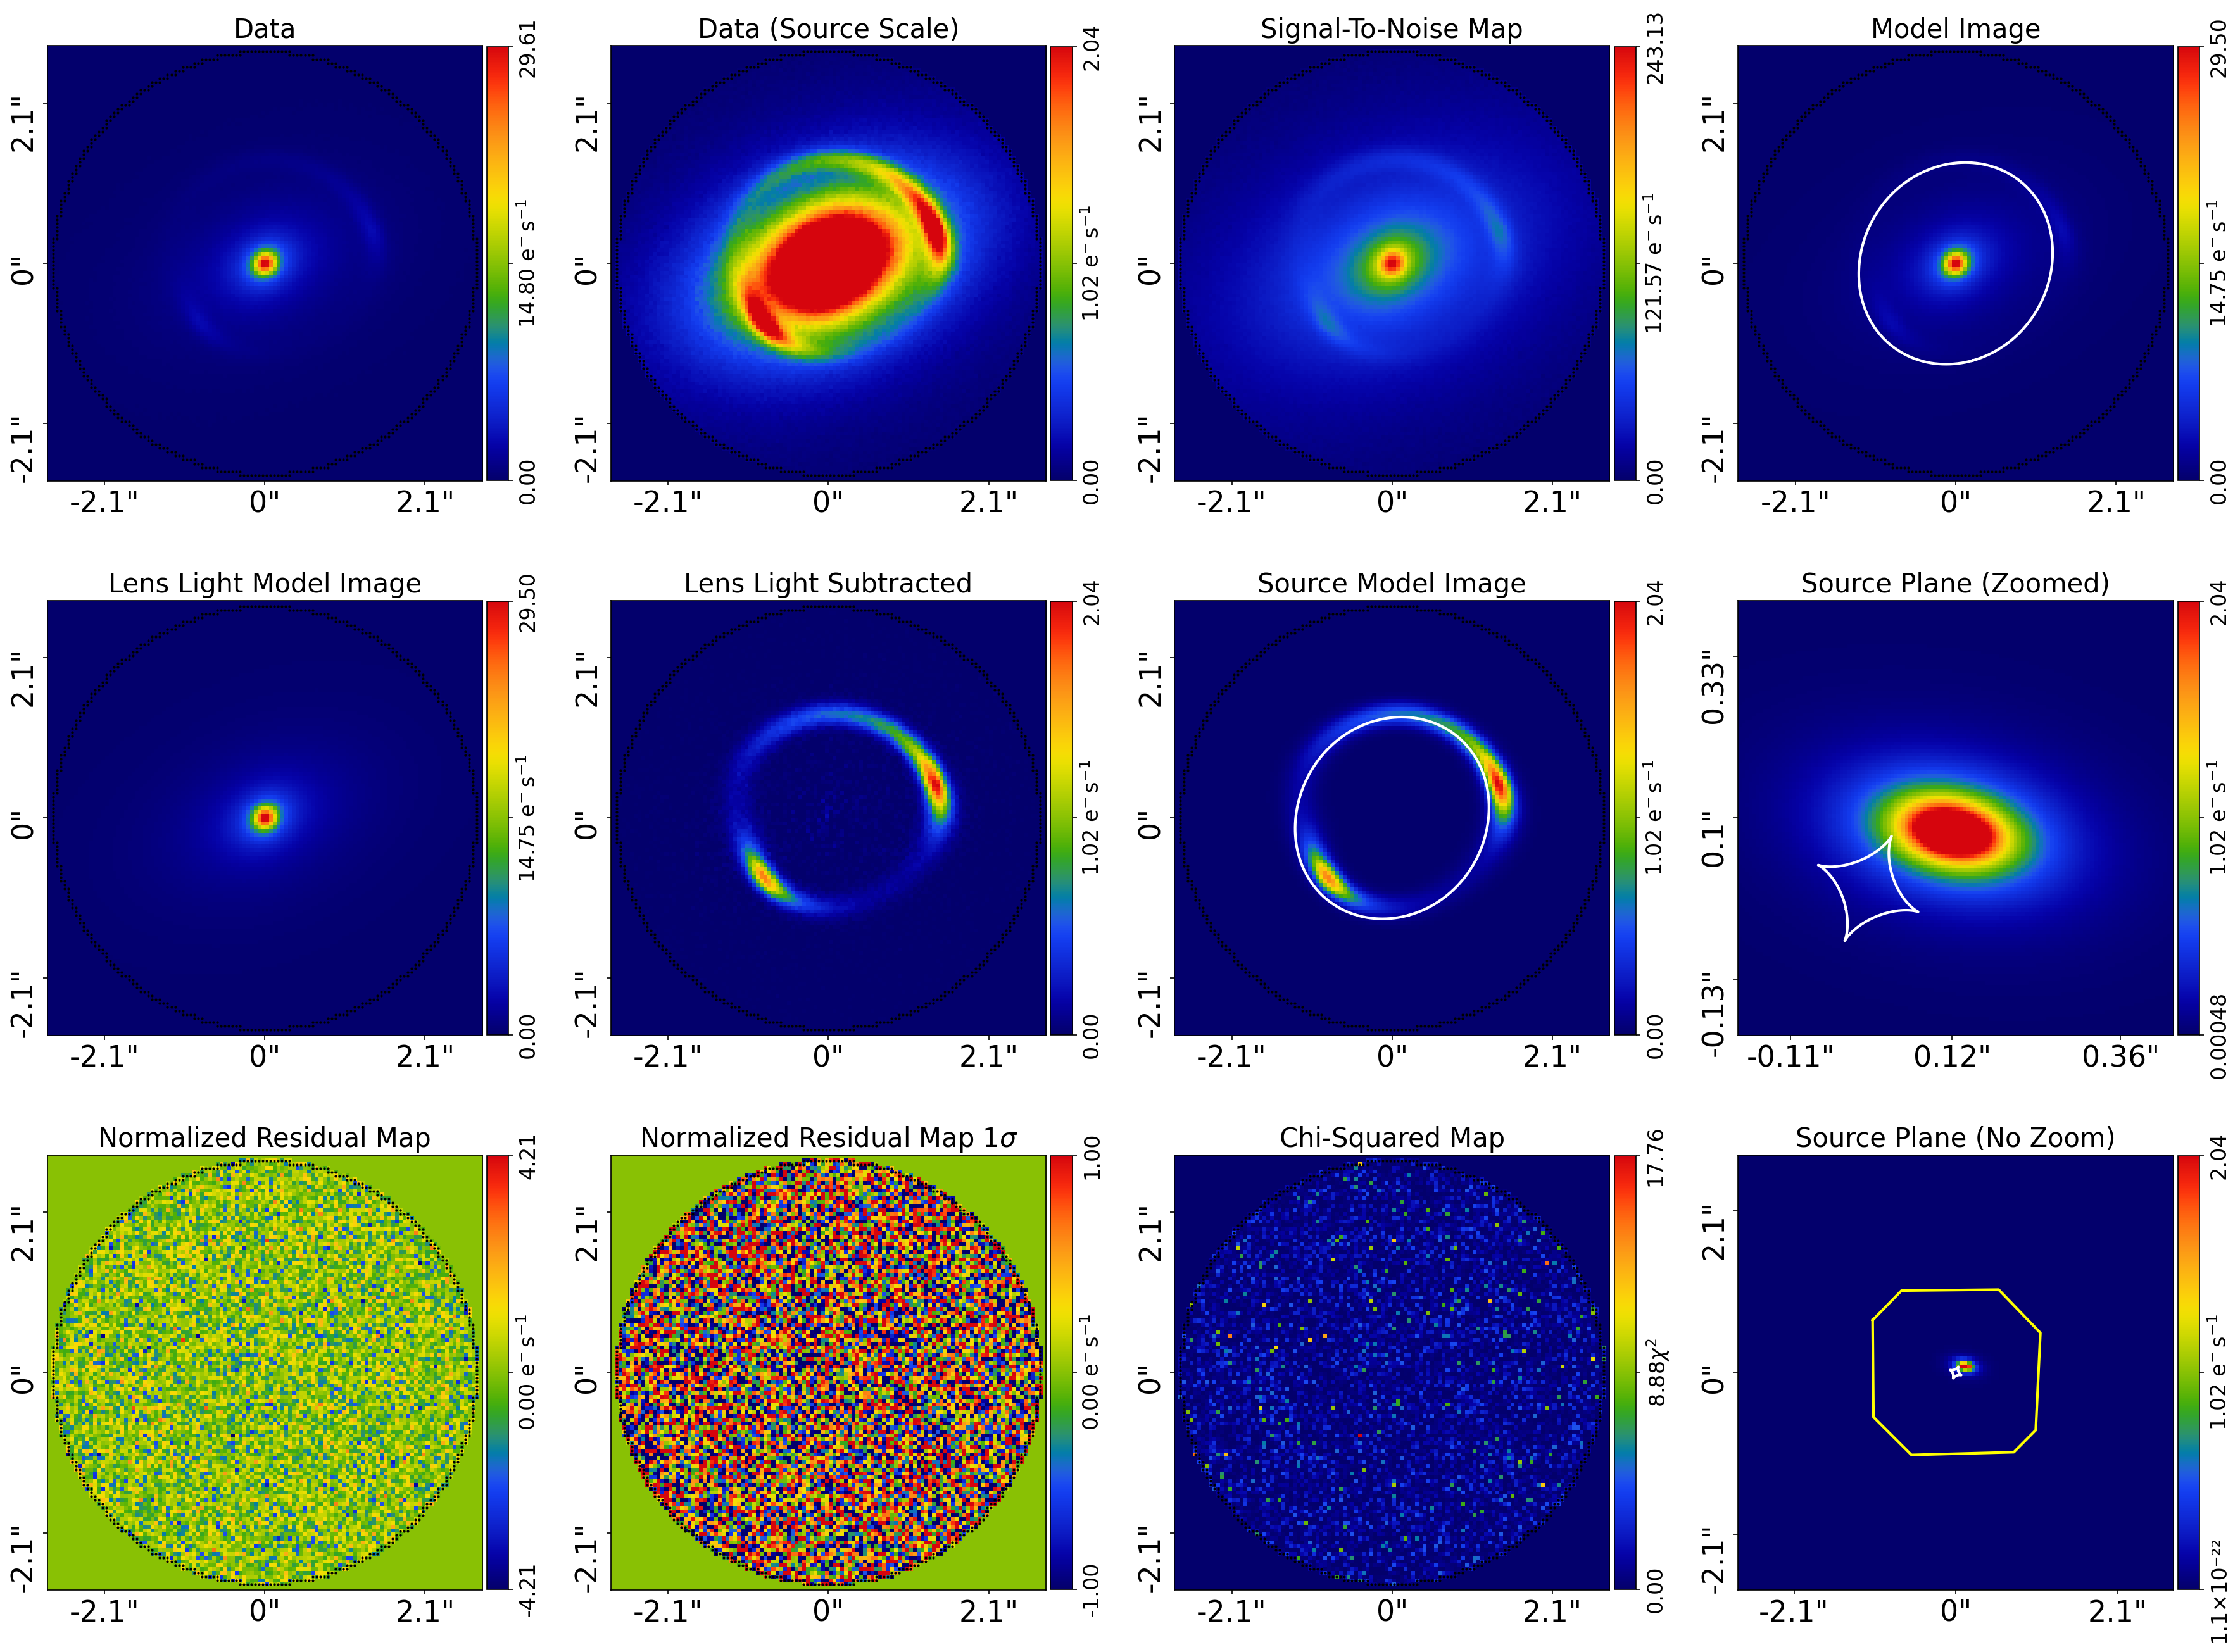

In [5]:
show_result("bulge_disk_fit")

---
## 4. Comparison

Both fits landed. Here are the committed numbers:

| | Single Sersic | Bulge + Disk |
|---|---|---|
| log_Z | **−33,256** | **+28,714** |
| χ²/N | 13.58 | 1.00 |
| max\|res\| | **43.2σ** (coherent 4-lobed cross at lens centre) | 4.21σ (salt-and-pepper; borderline SUSPECT on number, clean on physical) |
| n_params | 17 | 24 |
| Verdict | **Catastrophic FAIL** | **PASS** (physical bar clean) |

**Bayes factor** = exp(+28,714 − (−33,256)) ≈ **e⁶¹,⁹⁶⁹** — the 7 extra disk parameters are *massively* justified.

### Why single-Sersic fails this hard

Look at the single-Sersic fit's Normalized Residual Map: a **4-lobed red/blue cross at the lens centre**, magnitude > 40σ. This is the classic "wrong ellipticity / wrong PA" failure mode — a single Sersic locks to one effective ellipticity, so the residual maps out the azimuthal *difference* between the two truth components (bulge PA ≈ 0° and disk PA ≈ 35°). Adding 7 parameters (the second Sersic with independent ell_comps) lets the model rotate two components independently and the residual collapses to noise.

The Lens Light Subtracted panel tells the same story: the single-Sersic fit over-subtracts in one azimuth and under-subtracts in the perpendicular one, leaving a bright/dark residual pair. The bulge+disk fit subtracts cleanly, leaving only the Einstein ring visible.

### Read this as a generalisation

The "*n* Sersic components vs. *m* true components" ladder is worth internalising:

- If $m = 1$ (one smooth Sersic galaxy), one Sersic fit is sufficient.
- If $m = 2$ with *shared* PA (axisymmetric bulge + axisymmetric disk), one Sersic can approximate adequately — the total is still a single ellipse at that shared PA.
- **If $m = 2$ with *different* PAs** (as here), one Sersic fails catastrophically because a Sersic's brightness is fundamentally a single ellipse and cannot represent two orientations.
- If $m \geq 3$, or the morphology is spiral-arm-like or bar-like, two Sersics are no longer enough. That's the regime where MGE (Module 09) or non-parametric light models are required.

---

## 5. Exercises

1. **How disparate do the two PAs have to be before Variant 1 fails?** Regenerate the mock (`mocks/generate_mock.py`) with a smaller PA difference — say 10° between bulge and disk, instead of 35°. Refit both variants. At what PA difference does the Bayes factor drop below e¹⁰? (Below that, a single elliptical Sersic is a sufficient approximation.)

2. **Mass–light PA misalignment sanity check.** The mock has mass_PA = bulge_PA, not mass_PA = *total*-light_PA. If you had *only* Variant 1's single-Sersic lens light (which averages the two PAs), would you incorrectly tie mass_PA to that averaged light_PA? How much would that bias the recovered Einstein radius?

3. **Compare to MGE.** Module 09 shows MGE (Multi-Gaussian Expansion) handling arbitrary lens morphology with ~10 Gaussian components. Fit the same mock with an MGE-light lens and compare log_Z to the bulge+disk variant here. MGE should either match or beat — if it doesn't, the 2-Sersic decomposition is the natural ceiling for this mock's morphology.

---

## References

- Cappellari (2002), MNRAS 333, 400 — MGE parameterisation.
- Nightingale+18 §3 — parametric light profiles in PyAutoLens.
- `Modules/09_MGE_Linear_Light_Profiles/` — MGE pipeline in this repo.

---

*Learning to Autolens — Examples / disky_spiral_lens / 01*  
*Rodrigo Córdova Rosado, Harvard CfA*